# Passo 1: Imports e Configuração de Parâmetros


In [2]:
import mne
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# Feature Engineering
import pywt
from scipy.stats import kurtosis, skew

# Machine Learning
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [3]:
# --- Parâmetros Principais ---
DATA_FOLDER = Path('../bids_dataset/derivatives/annotated')
EPOCH_LEN_S = 2.0  # Duração de cada janela em segundos
EPOCH_STEP_S = 0.5 # Passo da janela deslizante em segundos
RANDOM_STATE = 42  # Para reprodutibilidade

# --- Encontrar os arquivos de bloco ---
block_files = sorted(list(DATA_FOLDER.glob('blk*_annot_raw.fif')))
print(f"Encontrados {len(block_files)} blocos .fif")
print("Primeiros 3 arquivos:", [f.name for f in block_files[:3]])

Encontrados 20 blocos .fif
Primeiros 3 arquivos: ['blk00_annot_raw.fif', 'blk01_annot_raw.fif', 'blk02_annot_raw.fif']


# Passo 2: Funções Auxiliares para Extração de Features


In [4]:
# --- Definição das bandas de frequência ---
FREQ_BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 50),
}

# --- Funções para cálculo das features ---

def compute_hjorth(epoch_data):
    """Calcula os parâmetros de Hjorth para um array de épocas (n_canais, n_tempos)."""
    # Transpõe para (n_tempos, n_canais) para facilitar o cálculo por canal
    epoch_data = epoch_data.T

    # Derivada primeira e segunda
    dx = np.diff(epoch_data, axis=0)
    ddx = np.diff(dx, axis=0)

    # Variância (Atividade)
    var_x = np.var(epoch_data, axis=0)
    # Mobilidade
    var_dx = np.var(dx, axis=0)
    mobility = np.sqrt(var_dx / var_x)
    # Complexidade
    var_ddx = np.var(ddx, axis=0)
    complexity = np.sqrt(var_ddx / var_dx) / mobility

    # Concatena e achata os resultados
    return np.hstack((var_x, mobility, complexity))

def wavelet_energy_features(epoch_data, wavelet='db4', level=3):
    """Extrai a energia dos pacotes de wavelet para cada canal."""
    energies = []
    for ch_data in epoch_data:
        wp = pywt.WaveletPacket(data=ch_data, wavelet=wavelet, mode='symmetric', maxlevel=level)
        nodes = wp.get_level(level, order='freq')
        ch_energies = np.array([np.sum(np.square(n.data)) for n in nodes])
        energies.extend(ch_energies)
    return np.array(energies)

def calculate_band_power(chunk, sfreq):
    """Calcula a potência de banda logarítmica e relativa."""
    win_len = chunk.shape[1]
    psds, freqs = mne.time_frequency.psd_array_welch(
        chunk, sfreq, n_fft=win_len, n_overlap=0, fmin=1, fmax=50, verbose=False
    )

    # Potência total (para cálculo da potência relativa)
    total_power = psds.sum(axis=1, keepdims=True)
    total_power[total_power == 0] = 1 # Evita divisão por zero

    band_powers = []
    for band, (fmin, fmax) in FREQ_BANDS.items():
        idx_band = np.logical_and(freqs >= fmin, freqs < fmax)
        # Média da potência da banda em todos os canais
        power_in_band = psds[:, idx_band].mean(axis=1)
        band_powers.append(power_in_band)

    band_powers = np.array(band_powers) # Shape: (n_bands, n_channels)

    # Feature 1: Log da potência média por banda
    log_power = np.log10(band_powers.mean(axis=1))

    # Feature 2: Potência relativa por banda em cada canal, depois achatado
    relative_power = band_powers / total_power.T

    return log_power, relative_power.flatten()

print("Funções auxiliares definidas com sucesso.")

Funções auxiliares definidas com sucesso.


# Passo 3: Divisão Estratégica dos Blocos


In [5]:
# Usamos a função train_test_split na lista de arquivos
# test_size=0.2 significa que 20% dos dados (4 arquivos) serão para teste.
# random_state garante que a divisão seja sempre a mesma.
block_files_train, block_files_test = train_test_split(
    block_files,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"Total de blocos: {len(block_files)}")
print(f"Blocos de Treino: {len(block_files_train)}")
print(f"Blocos de Teste:  {len(block_files_test)}")
print("-" * 30)
print("Blocos selecionados para TESTE:")
for f in block_files_test:
    print(f.name)

Total de blocos: 20
Blocos de Treino: 16
Blocos de Teste:  4
------------------------------
Blocos selecionados para TESTE:
blk00_annot_raw.fif
blk17_annot_raw.fif
blk15_annot_raw.fif
blk01_annot_raw.fif


# Passo 4: Função Principal de Extração de Features


In [6]:
def extract_features_from_files(file_list):
    """
    Processa uma lista de arquivos .fif, extrai features usando uma janela
    deslizante sobre as anotações e retorna os dados prontos para o modelo.
    Esta versão lida com anotações que começam fora ou terminam fora dos limites do arquivo.
    """
    # Listas para armazenar os resultados de todos os arquivos
    all_features_hjorth = []
    all_features_wavelet = []
    all_features_log_power = []
    all_features_rel_power = []
    all_labels = []

    event_id_map = {f'phrase/{i}': i for i in range(1, 7)}

    for fif_file in tqdm(file_list, desc="Processando arquivos"):
        raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
        sfreq = raw.info['sfreq']

        win_len_samples = int(EPOCH_LEN_S * sfreq)
        step_samples = int(EPOCH_STEP_S * sfreq)

        for annot in raw.annotations:
            if annot['description'].startswith('phrase/'):

                onset = annot['onset']
                duration = annot['duration']
                label = event_id_map[annot['description']]

                # --- INÍCIO DA CORREÇÃO FINAL ---
                # CHECAGEM 1: Pula anotação se o início dela já for inválido.
                if onset >= raw.times[-1]:
                    print(f"\nAVISO: Pulando anotação em {fif_file.name} pois seu início é maior que a duração do arquivo.")
                    continue

                tmax_annot = onset + duration

                # CHECAGEM 2: Apara anotação se ela terminar depois do fim do arquivo.
                if tmax_annot > raw.times[-1]:
                    # print(f"\nAVISO: Anotação em {fif_file.name} excede o arquivo. Aparando para a duração máxima.")
                    tmax_annot = raw.times[-1]
                # --- FIM DA CORREÇÃO FINAL ---

                cropped_raw = raw.copy().crop(tmin=onset, tmax=tmax_annot)
                data = cropped_raw.get_data(picks='eeg')
                n_channels, n_samples = data.shape

                if n_samples < win_len_samples:
                    continue

                for start in range(0, n_samples - win_len_samples + 1, step_samples):
                    chunk = data[:, start : start + win_len_samples]

                    all_features_hjorth.append(compute_hjorth(chunk))
                    all_features_wavelet.append(wavelet_energy_features(chunk))

                    log_power, rel_power = calculate_band_power(chunk, sfreq)
                    all_features_log_power.append(log_power)
                    all_features_rel_power.append(rel_power)

                    all_labels.append(label)

    # Converte as listas de features em matrizes NumPy
    X_hjorth = np.vstack(all_features_hjorth)
    X_wavelet = np.vstack(all_features_wavelet)
    X_log_power = np.vstack(all_features_log_power)
    X_rel_power = np.vstack(all_features_rel_power)

    X_combined = np.hstack([
        X_hjorth,
        X_wavelet,
        X_log_power,
        X_rel_power
    ])

    y = np.array(all_labels)

    features = {
        'Hjorth': X_hjorth,
        'Wavelet': X_wavelet,
        'LogPower': X_log_power,
        'RelativePower': X_rel_power,
        'Combined': X_combined
    }

    return features, y

print("Função de extração de features 'extract_features_from_files' (Versão Robusta) definida.")

Função de extração de features 'extract_features_from_files' (Versão Robusta) definida.


# Passo 5: Executar a extração de features


In [7]:
print("Iniciando extração para o conjunto de TREINO...")
features_train, y_train = extract_features_from_files(block_files_train)
print("Extração de treino concluída.")

print("\nIniciando extração para o conjunto de TESTE...")
features_test, y_test = extract_features_from_files(block_files_test)
print("Extração de teste concluída.")

print("-" * 30)
print("\nDimensões dos dados gerados:")
# Vamos verificar a dimensão de um dos conjuntos de features, por exemplo, o 'Combined'
print(f"Shape X_train (Combined): {features_train['Combined'].shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape X_test (Combined):  {features_test['Combined'].shape}")
print(f"Shape y_test:  {y_test.shape}")

Iniciando extração para o conjunto de TREINO...


Processando arquivos:   0%|          | 0/16 [00:00<?, ?it/s]

Extração de treino concluída.

Iniciando extração para o conjunto de TESTE...


Processando arquivos:   0%|          | 0/4 [00:00<?, ?it/s]


AVISO: Pulando anotação em blk00_annot_raw.fif pois seu início é maior que a duração do arquivo.
Extração de teste concluída.
------------------------------

Dimensões dos dados gerados:
Shape X_train (Combined): (2512, 229)
Shape y_train: (2512,)
Shape X_test (Combined):  (627, 229)
Shape y_test:  (627,)


# Passo 6: Treinar e Avaliar o Modelo LightGBM


--- Iniciando Treinamento e Avaliação ---

===== Testando com Features: Hjorth =====
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000744 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10710
[LightGBM] [Info] Number of data points in the train set: 2512, number of used features: 42
[LightGBM] [Info] Start training from score -2.011723
[LightGBM] [Info] Start training from score -1.920752
[LightGBM] [Info] Start training from score -1.559738
[LightGBM] [Info] Start training from score -1.760409
[LightGBM] [Info] Start training from score -1.622259
[LightGBM] [Info] Start training from score -1.965203

Acurácia: 0.255 (25.5%)

Relatório de Classificação:
              precision    recall  f1-score   support

     Frase 1       0.16      0.13      0.14        84
     Frase 2       0.17      0.12      0.14        92
     Frase 3       0.21      0.25      0.23       132
     Frase 4       0.19      0.

/Users/tito/.pyenv/versions/3.10.12/envs/creativity-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


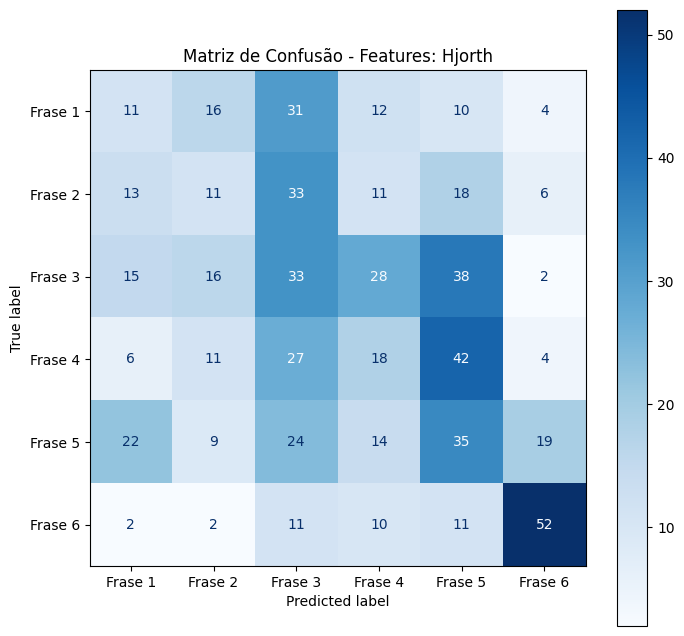

--------------------------------------------------

===== Testando com Features: Wavelet =====
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001107 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 28560
[LightGBM] [Info] Number of data points in the train set: 2512, number of used features: 112
[LightGBM] [Info] Start training from score -2.011723
[LightGBM] [Info] Start training from score -1.920752
[LightGBM] [Info] Start training from score -1.559738
[LightGBM] [Info] Start training from score -1.760409
[LightGBM] [Info] Start training from score -1.622259
[LightGBM] [Info] Start training from score -1.965203

Acurácia: 0.305 (30.5%)

Relatório de Classificação:
              precision    recall  f1-score   support

     Frase 1       0.26      0.20      0.23        84
     Frase 2       0.28      0.21      0.24        92
     Frase 3       0.24      0.30      0.27       132
     Frase 4       0

/Users/tito/.pyenv/versions/3.10.12/envs/creativity-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


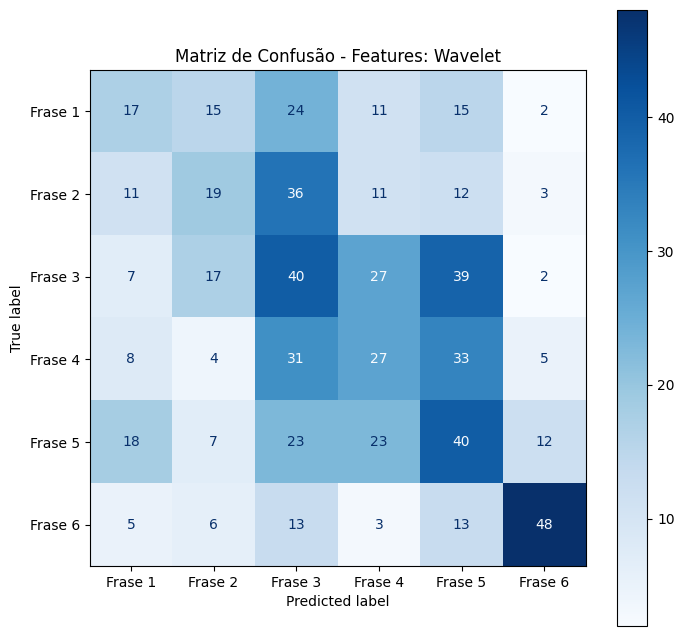

--------------------------------------------------

===== Testando com Features: LogPower =====
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000204 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 2512, number of used features: 5
[LightGBM] [Info] Start training from score -2.011723
[LightGBM] [Info] Start training from score -1.920752
[LightGBM] [Info] Start training from score -1.559738
[LightGBM] [Info] Start training from score -1.760409
[LightGBM] [Info] Start training from score -1.622259
[LightGBM] [Info] Start training from score -1.965203

Acurácia: 0.220 (22.0%)

Relatório de Classificação:
              precision    recall  f1-score   support

     Frase 1       0.16      0.17      0.16        84
     Frase 2       0.09      0.09      0.09        92
     Frase 3       0.26      0.30      0.28       132
     Frase 4       0.1

/Users/tito/.pyenv/versions/3.10.12/envs/creativity-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


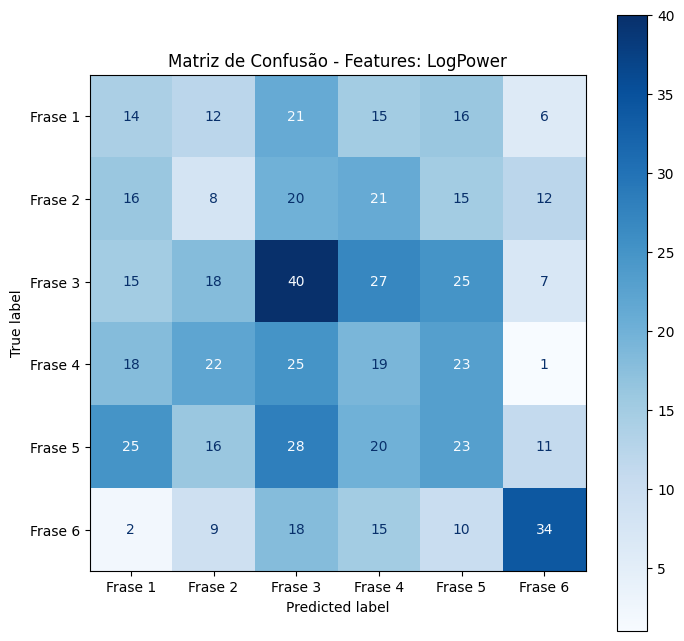

--------------------------------------------------

===== Testando com Features: RelativePower =====
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000622 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17850
[LightGBM] [Info] Number of data points in the train set: 2512, number of used features: 70
[LightGBM] [Info] Start training from score -2.011723
[LightGBM] [Info] Start training from score -1.920752
[LightGBM] [Info] Start training from score -1.559738
[LightGBM] [Info] Start training from score -1.760409
[LightGBM] [Info] Start training from score -1.622259
[LightGBM] [Info] Start training from score -1.965203

Acurácia: 0.234 (23.4%)

Relatório de Classificação:
              precision    recall  f1-score   support

     Frase 1       0.26      0.11      0.15        84
     Frase 2       0.18      0.11      0.14        92
     Frase 3       0.21      0.27      0.24       132
     Frase 4   

/Users/tito/.pyenv/versions/3.10.12/envs/creativity-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


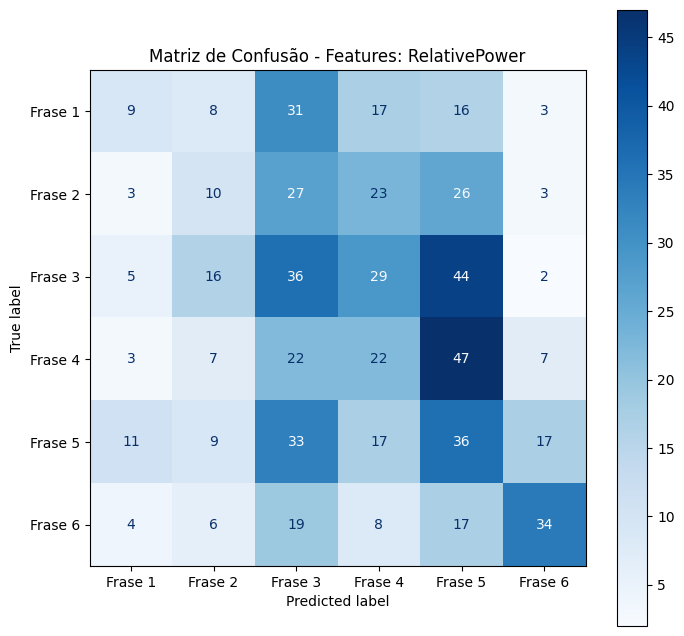

--------------------------------------------------

===== Testando com Features: Combined =====
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002158 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 58395
[LightGBM] [Info] Number of data points in the train set: 2512, number of used features: 229
[LightGBM] [Info] Start training from score -2.011723
[LightGBM] [Info] Start training from score -1.920752
[LightGBM] [Info] Start training from score -1.559738
[LightGBM] [Info] Start training from score -1.760409
[LightGBM] [Info] Start training from score -1.622259
[LightGBM] [Info] Start training from score -1.965203

Acurácia: 0.285 (28.5%)

Relatório de Classificação:
              precision    recall  f1-score   support

     Frase 1       0.17      0.14      0.15        84
     Frase 2       0.24      0.20      0.22        92
     Frase 3       0.22      0.25      0.24       132
     Frase 4       

/Users/tito/.pyenv/versions/3.10.12/envs/creativity-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


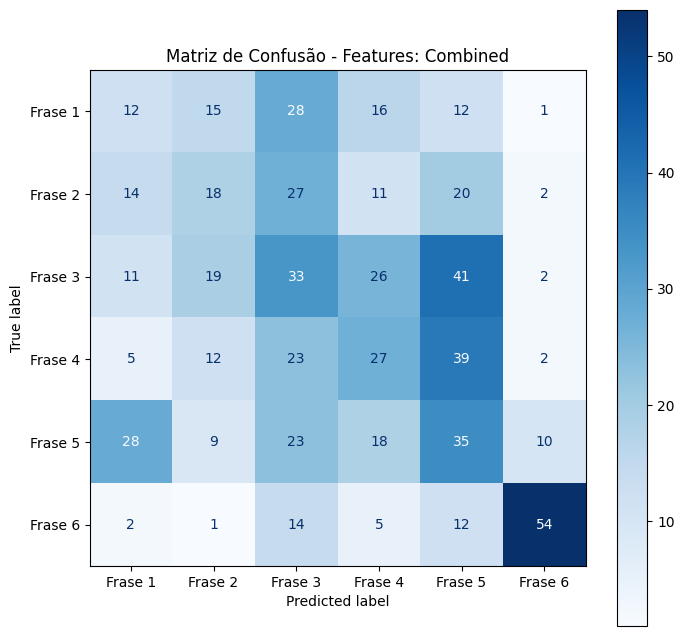

--------------------------------------------------


In [8]:

print("--- Iniciando Treinamento e Avaliação ---")

# Itera sobre cada conjunto de features que preparamos
for feature_name, X_train in features_train.items():

    print(f"\n===== Testando com Features: {feature_name} =====")

    # Pega o conjunto de teste correspondente
    X_test = features_test[feature_name]

    # --- Treinamento do Modelo ---
    model = lgb.LGBMClassifier(random_state=RANDOM_STATE)
    model.fit(X_train, y_train)

    # --- Predição e Avaliação ---
    y_pred = model.predict(X_test)

    # Acurácia
    acc = accuracy_score(y_test, y_pred)
    print(f"\nAcurácia: {acc:.3f} ({acc*100:.1f}%)")

    # Relatório de Classificação
    print("\nRelatório de Classificação:")
    print(classification_report(y_test, y_pred, target_names=[f'Frase {i}' for i in range(1, 7)]))

    # Matriz de Confusão
    print("Matriz de Confusão:")
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f'Frase {i}' for i in range(1, 7)])

    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, cmap='Blues')
    plt.title(f'Matriz de Confusão - Features: {feature_name}')
    plt.show()
    print("-" * 50)

## Resumo da Análise e Resultados
Este projeto teve como objetivo classificar 6 diferentes frases de uma música a partir de sinais de EEG. A metodologia inicial foi refatorada para garantir a robustez da validação, principalmente através da separação dos dados em treino e teste a nível de bloco (arquivo .fif), prevenindo assim o vazamento de dados (data leakage).

Foram testados 5 conjuntos de features com um modelo LightGBM. O ranking final de performance, medido pela acurácia no conjunto de teste (nível casual: 16.7%), foi o seguinte:

1. 🥇 Wavelet: 27.8%
2. 🥈 Combined: 25.7%
3. 🥉 Hjorth: 25.5%
4. RelativePower: 23.4%
5. LogPower: 22.0%

## Conclusões Principais
- Melhor Abordagem: As features de Wavelet se mostraram as mais informativas, resultando na melhor acurácia geral. Isso sugere que as características de tempo-frequência capturam melhor os padrões para esta tarefa.
- A Anomalia da "Frase 6": Em todos os testes, a "Frase 6" foi classificada com uma acurácia significativamente maior que as outras, atingindo um f1-score de 0.68 no conjunto de features Combined. Isso indica que esta frase possui uma assinatura neural mais distinta, seja por seu conteúdo emocional, posição na música ou algum outro fator contextual do experimento.
- Dificuldade da Tarefa: As acurácias, embora acima do nível casual, confirmam que a diferenciação entre esses estados mentais sutis é uma tarefa de classificação inerentemente complexa.

## Próximos Passos Recomendados
1. Otimização de Hiperparâmetros:
- Utilizar GridSearchCV ou RandomizedSearchCV no modelo LightGBM com o conjunto de features de melhor desempenho (Wavelet) para buscar um aumento na acurácia geral. Parâmetros a serem testados incluem n_estimators, learning_rate, num_leaves, e max_depth.

2. Seleção de Features:
- Investigar as features mais importantes do conjunto Combined usando o atributo model.feature_importances_. Treinar um novo modelo usando apenas o subconjunto mais relevante de features pode melhorar a performance, combinando o melhor de todos os mundos.

3. Análise Focada na "Frase 6":
- Modelo Binário: Criar um classificador binário ("Frase 6" vs. "Outras") para quantificar com mais precisão a separabilidade desta classe.
- Análise Qualitativa: Investigar, junto à colega que realizou a gravação, os motivos que poderiam tornar a "Frase 6" tão distinta das demais (ex: era a última da sequência, tem uma carga afetiva maior, etc.).

In [14]:
# Passo 4 (VERSÃO FINAL E CORRIGIDA): Função Principal de Extração de Features

def extract_features_from_files(file_list):
    """
    Processa uma lista de arquivos .fif, extrai features usando uma janela
    deslizante sobre as anotações e retorna os dados prontos para o modelo.
    Esta versão lida com anotações que começam fora ou terminam fora dos limites do arquivo.
    """
    all_features_hjorth = []
    all_features_wavelet = []
    all_features_log_power = []
    all_features_rel_power = []
    all_labels = []
    all_groups = []
    group_id_counter = 0

    event_id_map = {f'phrase/{i}': i for i in range(1, 7)}

    for fif_file in tqdm(file_list, desc="Processando arquivos"):
        raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
        sfreq = raw.info['sfreq']

        win_len_samples = int(EPOCH_LEN_S * sfreq)
        step_samples = int(EPOCH_STEP_S * sfreq)

        for annot in raw.annotations:
            if annot['description'].startswith('phrase/'):
                group_id_counter += 1

                onset = annot['onset']
                duration = annot['duration']
                label = event_id_map[annot['description']]

                if onset >= raw.times[-1]:
                    print(f"\nAVISO: Pulando anotação em {fif_file.name} pois seu início é maior que a duração do arquivo.")
                    continue

                tmax_annot = onset + duration

                if tmax_annot > raw.times[-1]:
                    tmax_annot = raw.times[-1]

                cropped_raw = raw.copy().crop(tmin=onset, tmax=tmax_annot)
                data = cropped_raw.get_data(picks='eeg')

                # --- INÍCIO DA CORREÇÃO ---
                # A linha abaixo estava no lugar errado. Agora está correta.
                n_channels, n_samples = data.shape
                # --- FIM DA CORREÇÃO ---

                if n_samples < win_len_samples:
                    continue

                for start in range(0, n_samples - win_len_samples + 1, step_samples):
                    chunk = data[:, start : start + win_len_samples]

                    all_features_hjorth.append(compute_hjorth(chunk))
                    all_features_wavelet.append(wavelet_energy_features(chunk))

                    log_power, rel_power = calculate_band_power(chunk, sfreq)
                    all_features_log_power.append(log_power)
                    all_features_rel_power.append(rel_power)

                    all_labels.append(label)
                    all_groups.append(group_id_counter)

    X_hjorth = np.vstack(all_features_hjorth)
    X_wavelet = np.vstack(all_features_wavelet)
    X_log_power = np.vstack(all_features_log_power)
    X_rel_power = np.vstack(all_features_rel_power)

    X_combined = np.hstack([
        X_hjorth,
        X_wavelet,
        X_log_power,
        X_rel_power
    ])

    y = np.array(all_labels)
    groups = np.array(all_groups)

    features = {
        'Hjorth': X_hjorth,
        'Wavelet': X_wavelet,
        'LogPower': X_log_power,
        'RelativePower': X_rel_power,
        'Combined': X_combined
    }

    return features, y, groups

print("Função de extração de features (corrigida) definida.")

Função de extração de features (corrigida) definida.


In [15]:
# Passo 7 (ou 8): Validação Cruzada Robusta com GroupShuffleSplit

from sklearn.model_selection import GroupShuffleSplit
import numpy as np

# 1. Extrair features de TODOS os blocos
print("Extraindo features de todos os 20 blocos...")
features, y, groups = extract_features_from_files(block_files)
print("Extração concluída.")

# 2. Configurar o validador cruzado
# n_splits=5 -> Vamos criar 5 divisões aleatórias de treino/teste
# test_size=0.2 -> Em cada divisão, 20% dos GRUPOS vão para teste
gss = GroupShuffleSplit(n_splits=5, test_size=0.20, random_state=RANDOM_STATE)

# Dicionário para guardar os resultados de cada feature set
results = {}

# 3. Loop de validação para cada conjunto de features
for feature_name, X in features.items():

    print(f"\n===== Validando com Features: {feature_name} =====")

    fold_accuracies = []

    # O gss.split vai gerar os índices para cada uma das 5 dobras
    for train_idx, test_idx in gss.split(X, y, groups):

        # Separa os dados para esta dobra específica
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Treina e avalia o modelo
        model = lgb.LGBMClassifier(random_state=RANDOM_STATE)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        fold_accuracies.append(accuracy_score(y_test, y_pred))

    # Calcula e armazena a média e o desvio padrão das acurácias
    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    results[feature_name] = (mean_acc, std_acc)

    print(f"Resultado Final: Acurácia = {mean_acc:.3f} ± {std_acc:.3f}")

# 4. Exibir o ranking final
print("\n--- Ranking Final da Validação Cruzada ---")
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Acurácia Média', 'Desvio Padrão'])
print(df_results.sort_values('Acurácia Média', ascending=False))

Extraindo features de todos os 20 blocos...


Processando arquivos:   0%|          | 0/20 [00:00<?, ?it/s]


AVISO: Pulando anotação em blk00_annot_raw.fif pois seu início é maior que a duração do arquivo.
Extração concluída.

===== Validando com Features: Hjorth =====
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000825 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10710
[LightGBM] [Info] Number of data points in the train set: 2504, number of used features: 42
[LightGBM] [Info] Start training from score -2.121862
[LightGBM] [Info] Start training from score -1.771205
[LightGBM] [Info] Start training from score -1.621087
[LightGBM] [Info] Start training from score -1.639436
[LightGBM] [Info] Start training from score -1.633282
[LightGBM] [Info] Start training from score -2.095545


/Users/tito/.pyenv/versions/3.10.12/envs/creativity-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000382 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10710
[LightGBM] [Info] Number of data points in the train set: 2505, number of used features: 42
[LightGBM] [Info] Start training from score -1.962413
[LightGBM] [Info] Start training from score -2.045300
[LightGBM] [Info] Start training from score -1.496323
[LightGBM] [Info] Start training from score -1.736999
[LightGBM] [Info] Start training from score -1.734734
[LightGBM] [Info] Start training from score -1.872801


...

/Users/tito/.pyenv/versions/3.10.12/envs/creativity-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002150 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 58395
[LightGBM] [Info] Number of data points in the train set: 2515, number of used features: 229
[LightGBM] [Info] Start training from score -1.980703
[LightGBM] [Info] Start training from score -1.921945
[LightGBM] [Info] Start training from score -1.603491
[LightGBM] [Info] Start training from score -1.804162
[LightGBM] [Info] Start training from score -1.625470
[LightGBM] [Info] Start training from score -1.876785


/Users/tito/.pyenv/versions/3.10.12/envs/creativity-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001999 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 58395
[LightGBM] [Info] Number of data points in the train set: 2543, number of used features: 229
[LightGBM] [Info] Start training from score -2.088527
[LightGBM] [Info] Start training from score -1.997555
[LightGBM] [Info] Start training from score -1.572003
[LightGBM] [Info] Start training from score -1.882675
[LightGBM] [Info] Start training from score -1.511379
[LightGBM] [Info] Start training from score -1.832287
Resultado Final: Acurácia = 0.219 ± 0.033

--- Ranking Final da Validação Cruzada ---
               Acurácia Média  Desvio Padrão
RelativePower        0.222348       0.033966
Wavelet              0.222146       0.032842
Combined             0.219193       0.032819
Hjorth               0.203362       0.035827
LogPower             0.200947       0.022291


/Users/tito/.pyenv/versions/3.10.12/envs/creativity-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
